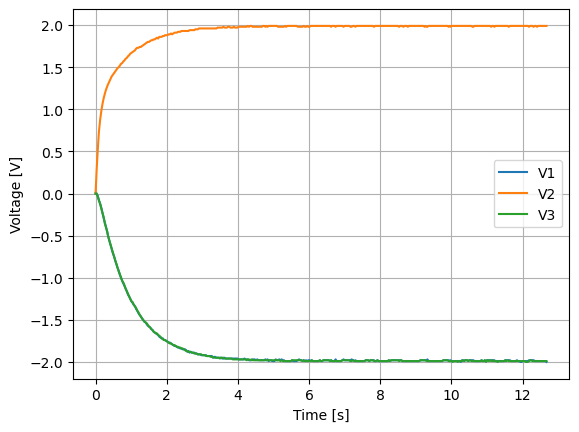

In [1135]:
#! pip install --upgrade ipython
#! pip install ipympl
#! pip install pyserial
# -----------------------------------------------------------------------
import time
import serial
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
from scipy.optimize import curve_fit
from  cycler import cycler

# -----------------------------------------------------------------------
# Max time steps to measure
max_iter = 400

# Input functions for voltage sources
u1 = lambda t: 0
u2 = lambda t: 3
u3 = lambda t: 0#2 + 0.5*np.sin(t*(2*np.pi))

name = 'u2_step_3V.csv'

# -----------------------------------------------------------------------

# Establish Serial object with COM port and BAUD rate to match Arduino
try:
    ser = serial.Serial("COM9", 9600,timeout=1)
except:
    ser.close()  
    ser = serial.Serial("COM9", 9600,timeout=1)

# -----------------------------------------------------------------------
# Time delay for Arduino Serial initialization 
time.sleep(4)  

# Time vector
tt = np.zeros(max_iter)
# vector of voltages, rows = time, cols = values
y = np.zeros((max_iter,3))

# Loop over time steps to
for i in range(max_iter):
    # Add current time to time vector
    tt[i] = time.time()
    # Time relative to start
    t = tt[i]-tt[0]
    # Compute input voltages
    v1 = u1(t)
    v2 = u2(t)
    v3 = u3(t)
    # Convert 0-5 V to 0-255 bit range for PWM
    v_in = [int(v1*51),int(v2*51),int(v3*51)]
    # String of input values
    dig_v = ",".join(map(str, v_in)) + "\n"
    # Sent string to Arduino
    ser.write(str(dig_v).encode('utf-8'))
    # Read back the component voltages for the Arduino
    arduinoData_string = ser.readline().decode('ascii').split(",")
    # Convert srting to voltage values (float)
    values = [float(i) for i in arduinoData_string[0:-1]]
    # Store in voltage vector
    y[i,:] = values

# Set voltages to 0 once done
v_in = [0,0,0]
dig_v = ",".join(map(str, v_in)) + "\n"
ser.write(str(dig_v).encode('utf-8'))
# Close serial connection
ser.close()

# Time vector relative to start
t = tt - tt[0]

# Pretty plot parameters
plt.rcParams['figure.figsize'] = [5, 3]
plt.rcParams.update({
    "text.usetex": False,
    "mathtext.fontset": "cm",
    "font.family": "serif",
    "font.serif": "cmr10",
    "axes.formatter.use_mathtext": True})

plt.rcParams["axes.prop_cycle"] = cycler(color=['b','r','g','orange',
                                                'm','dimgray'])

# Plot results
plt.plot(t,y,label=['V1','V2','V3'])
plt.xlabel('Time [s]')
plt.ylabel('Voltage [V]')
plt.legend()
plt.grid()
plt.show()

# Save data to csv file
data = np.hstack([t[:,np.newaxis],y])
np.savetxt(name, data, delimiter=",")


In [1027]:
ser.close()

# Fit $u_1$ Response

C:\Users\pheng\AppData\Local\Temp\ipykernel_22224\209415514.py:34: RuntimeWarning: overflow encountered in exp
  -tau1*(1-np.exp(-t/tau1))+tau3*(np.exp(-t/tau2)\
C:\Users\pheng\AppData\Local\Temp\ipykernel_22224\209415514.py:35: RuntimeWarning: overflow encountered in exp
  -np.exp(-t/tau1)))/(tau2-tau1)
C:\Users\pheng\AppData\Local\Temp\ipykernel_22224\209415514.py:33: RuntimeWarning: invalid value encountered in add
  g31 = lambda t,K,tau1,tau2,tau3: K*(tau2*(1-np.exp(-t/tau2))\


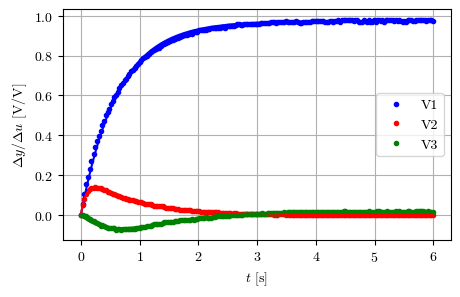

In [1985]:
# -----------------------------------------------------------------------
# Pretty plot parameters
plt.rcParams['figure.figsize'] = [5, 3]
plt.rcParams.update({
    "text.usetex": False,
    "mathtext.fontset": "cm",
    "font.family": "serif",
    "font.serif": "cmr10",
    "axes.formatter.use_mathtext": True})

plt.rcParams["axes.prop_cycle"] = cycler(color=['b','r','g','orange',
                                                'm','dimgray'])

# Name for fitting data
name = 'u1_step_3V.csv'
# Step magnitude
du = 3
# Max time to plot over
t_max = 6

# -----------------------------------------------------------------------
# load data
data = np.loadtxt(name, delimiter=',')
# Store time in vector
t = data[:,0]
# Store responses in matrix
y = data[:,1:]/du

# Perform least squares on I/O data using assumed model
g11 = lambda t,K,tau1: K*(1-np.exp(-t/tau1))
g21 = lambda t,K,tau1,tau2: K*(np.exp(-t/tau1)-np.exp(-t/tau2))
g31 = lambda t,K,tau1,tau2,tau3: K*(tau2*(1-np.exp(-t/tau2))\
                                -tau1*(1-np.exp(-t/tau1))\
                                    +tau3*(np.exp(-t/tau2)\
                                -np.exp(-t/tau1)))/(tau2-tau1)

# Fit parameters
p11, pcov11 = curve_fit(g11,t,y[:,0])
p21, pcov21 = curve_fit(g21,t,y[:,1],p0=[1,1,2])
p31, pcov31 = curve_fit(g31,t,y[:,2],p0=[0.5,1,2,-0.1])


# Plot model vs data
fig, ax = plt.subplots()
plt.plot(t[t<t_max],y[t<t_max,:],linestyle='none',marker='.',
         label=['V1','V2','V3'])
plt.plot(t[t<t_max],g11(t[t<t_max],*p11),color='b')
plt.plot(t[t<t_max],g21(t[t<t_max],*p21),color='r')
plt.plot(t[t<t_max],g31(t[t<t_max],*p31),color='g')
plt.xlabel('$t$ [s]')
plt.ylabel('$\Delta y/\Delta u$ [V/V]')
plt.legend()
plt.grid()
plt.show()
fig.savefig('CHEN_5300_u1_step_3V.png',dpi=600,bbox_inches='tight')
# -----------------------------------------------------------------------

# Verify $u_1$ Response

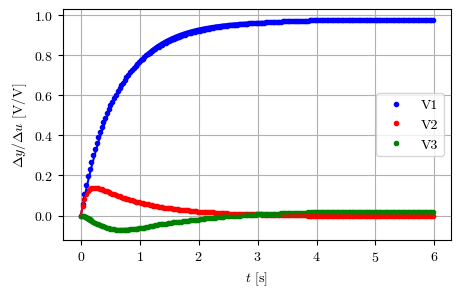

In [1988]:
# -----------------------------------------------------------------------
# Plot model vs data on different data
name = 'u1_step_5V.csv'

data = np.loadtxt(name, delimiter=',')

du = 5
t = data[:,0]
y = data[:,1:]/du

fig, ax = plt.subplots()
plt.plot(t[t<t_max],y[t<t_max,:],linestyle='none',marker='.',
         label=['V1','V2','V3'])
plt.plot(t[t<t_max],g11(t[t<t_max],*p11),color='b')
plt.plot(t[t<t_max],g21(t[t<t_max],*p21),color='r')
plt.plot(t[t<t_max],g31(t[t<t_max],*p31),color='g')
plt.xlabel('$t$ [s]')
plt.ylabel('$\Delta y/\Delta u$ [V/V]')
plt.legend()
plt.grid()
plt.show()
fig.savefig('CHEN_5300_u1_step_5V.png',dpi=600,bbox_inches='tight')
# -----------------------------------------------------------------------

# Fit $u_2$ Response

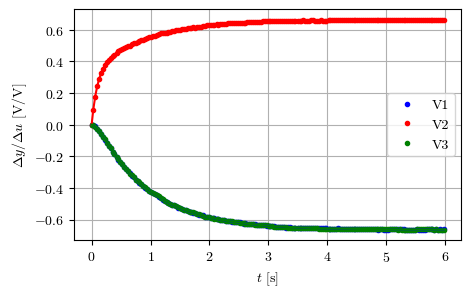

In [1990]:
# -----------------------------------------------------------------------
# Name for fitting data
name = 'u2_step_3V.csv'
# Step magnitude
du = 3
# -----------------------------------------------------------------------
# load data
data = np.loadtxt(name, delimiter=',')
# Store time in vector
t = data[:,0]
# Store responses in matrix
y = data[:,1:]/du

# Perform least squares on I/O data using assumed model
g12 = lambda t,K,tau1,tau2: K*(1+tau1*np.exp(-t/tau1)/(tau2-tau1)\
                               -tau2*np.exp(-t/tau2)/(tau2-tau1))
g22 = lambda t,K,tau1,tau2,tau3: K*(tau2*(1-np.exp(-t/tau2))-tau1\
                                    *(1-np.exp(-t/tau1))\
                                    +tau3*(np.exp(-t/tau2)\
                                    -np.exp(-t/tau1)))/(tau2-tau1)
g32 = lambda t,K,tau1,tau2: K*(1+tau1*np.exp(-t/tau1)/(tau2-tau1)-tau2\
                               *np.exp(-t/tau2)/(tau2-tau1))

# Fit parameters
p12, pcov12 = curve_fit(g12,t,y[:,0],p0=[-0.5,0.1,0.2])
p22, pcov22 = curve_fit(g22,t,y[:,1],p0=[0.60,1,0.1,0.5])
p32, pcov32 = curve_fit(g32,t,y[:,2],p0=[-0.5,0.1,0.2])

# Plot model vs data
fig, ax = plt.subplots()
plt.plot(t[t<t_max],y[t<t_max,:],linestyle='none',marker='.',
         label=['V1','V2','V3'])
plt.plot(t[t<t_max],g12(t[t<t_max],*p12),color='b')
plt.plot(t[t<t_max],g22(t[t<t_max],*p22),color='r')
plt.plot(t[t<t_max],g32(t[t<t_max],*p32),color='g')
plt.xlabel('$t$ [s]')
plt.ylabel('$\Delta y/\Delta u$ [V/V]')
plt.legend()
plt.grid()
plt.show()
fig.savefig('CHEN_5300_u2_step_3V.png',dpi=600,bbox_inches='tight')
# -----------------------------------------------------------------------

# Verify $u_2$ Response

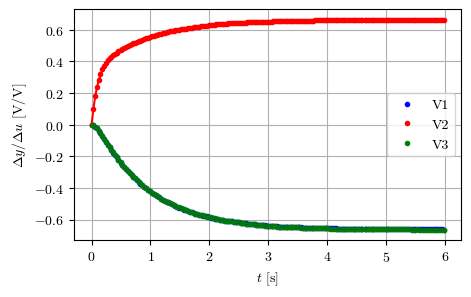

In [1992]:
# -----------------------------------------------------------------------
# Plot model vs data on different data
name = 'u2_step_5V.csv'

data = np.loadtxt(name, delimiter=',')
du = 5
t = data[:,0]
y = data[:,1:]/du

fig, ax = plt.subplots()
plt.plot(t[t<t_max],y[t<t_max,:],linestyle='none',marker='.',
         label=['V1','V2','V3'])
plt.plot(t[t<t_max],g12(t[t<t_max],*p12),color='b')
plt.plot(t[t<t_max],g22(t[t<t_max],*p22),color='r')
plt.plot(t[t<t_max],g32(t[t<t_max],*p32),color='g')
plt.xlabel('$t$ [s]')
plt.ylabel('$\Delta y/\Delta u$ [V/V]')
plt.legend()
plt.grid()
plt.show()
fig.savefig('CHEN_5300_u2_step_5V.png',dpi=600,bbox_inches='tight')
# -----------------------------------------------------------------------

# Fit $u_3$ Response

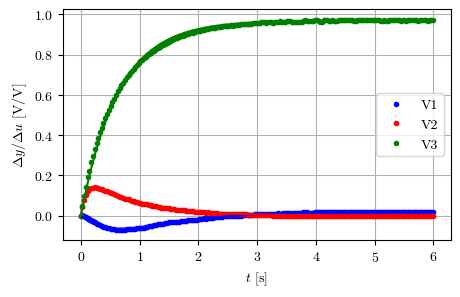

In [1994]:
# -----------------------------------------------------------------------
# Name for fitting data
name = 'u3_step_3V.csv'
# Step magnitude
du = 3
# -----------------------------------------------------------------------
# load data
data = np.loadtxt(name, delimiter=',')
# Store time in vector
t = data[:,0]
# Store responses in matrix
y = data[:,1:]/du

# Perform least squares on I/O data using assumed model
g33 = lambda t,K,tau1: K*(1-np.exp(-t/tau1))
g23 = lambda t,K,tau1,tau2: K*(np.exp(-t/tau1)-np.exp(-t/tau2))
g13 = lambda t,K,tau1,tau2,tau3: K*(tau2*(1-np.exp(-t/tau2))\
                                -tau1*(1-np.exp(-t/tau1))\
                                    +tau3*(np.exp(-t/tau2)\
                                -np.exp(-t/tau1)))/(tau2-tau1)

# Fit parameters
p13, pcov13 = curve_fit(g13,t,y[:,0],p0=[-0.5,0.1,0.2,-0.1])
p23, pcov23 = curve_fit(g23,t,y[:,1],p0=[0.60,1,0.1])
p33, pcov33 = curve_fit(g33,t,y[:,2])

# Plot model vs data
fig, ax = plt.subplots()
plt.plot(t[t<t_max],y[t<t_max,:],linestyle='none',marker='.',
         label=['V1','V2','V3'])
plt.plot(t[t<t_max],g13(t[t<t_max],*p13),color='b')
plt.plot(t[t<t_max],g23(t[t<t_max],*p23),color='r')
plt.plot(t[t<t_max],g33(t[t<t_max],*p33),color='g')
plt.xlabel('$t$ [s]')
plt.ylabel('$\Delta y/\Delta u$ [V/V]')
plt.legend()
plt.grid()
plt.show()
fig.savefig('CHEN_5300_u3_step_3V.png',dpi=600,bbox_inches='tight')
# -----------------------------------------------------------------------

# Verify $u_3$ Response

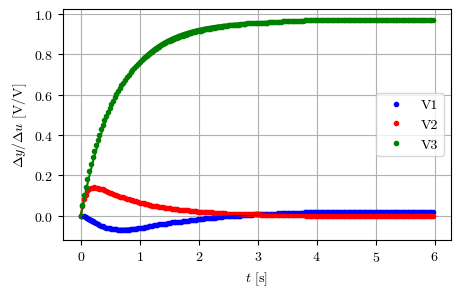

In [1996]:
# -----------------------------------------------------------------------
# Plot model vs data on different data
name = 'u3_step_5V.csv'

data = np.loadtxt(name, delimiter=',')
du = 5
t = data[:,0]
y = data[:,1:]/du

fig, ax = plt.subplots()
plt.plot(t[t<t_max],y[t<t_max,:],linestyle='none',marker='.',
         label=['V1','V2','V3'])
plt.plot(t[t<t_max],g13(t[t<t_max],*p13),color='b')
plt.plot(t[t<t_max],g23(t[t<t_max],*p23),color='r')
plt.plot(t[t<t_max],g33(t[t<t_max],*p33),color='g')
plt.xlabel('$t$ [s]')
plt.ylabel('$\Delta y/\Delta u$ [V/V]')
plt.legend()
plt.grid()
plt.show()
fig.savefig('CHEN_5300_u3_step_5V.png',dpi=600,bbox_inches='tight')
# -----------------------------------------------------------------------

# Setup Transfer Function Matrix

In [2008]:
# -----------------------------------------------------------------------
import control as ct
# -----------------------------------------------------------------------
# Laplace variable
s = ct.tf('s')

# First column of G
G11 = p11[0]/(p11[1]*s+1)
G21 = p21[0]*(p21[1]*s/(p21[1]*s+1)-p21[2]*s/(p21[2]*s+1))
G31 = p31[0]*(p31[3]*s+1)/((p31[1]*s+1)*(p31[2]*s+1))
# Second column of G
G12 = p12[0]/((p12[1]*s+1)*(p12[2]*s+1))
G22 = p22[0]*(p22[3]*s+1)/((p22[1]*s+1)*(p22[2]*s+1))
G32 = p32[0]/((p32[1]*s+1)*(p32[2]*s+1))
# Third column of G
G13 = p13[0]*(p13[3]*s+1)/((p13[1]*s+1)*(p13[2]*s+1))
G23 = p23[0]*(p23[1]*s/(p23[1]*s+1)-p23[2]*s/(p23[2]*s+1))
G33 = p33[0]/(p33[1]*s+1)

# Total transfer function matrix
G = ct.tf([[G11, G12, G13],
           [G21, G22, G23],
           [G31, G32, G33]])

# Steady state gain matrix
K = np.real(G(0))

# Relative Gain Array
RGA = K*np.linalg.inv(K).T

# Print gain and RGA matrices
print(K)
print(RGA)
# -----------------------------------------------------------------------

[[ 0.97322561 -0.66241403  0.01894771]
 [ 0.          0.66302686  0.        ]
 [ 0.01875658 -0.66297108  0.96877879]]
[[ 1.00037708e+00 -0.00000000e+00 -3.77082041e-04]
 [ 0.00000000e+00  1.00000000e+00  0.00000000e+00]
 [-3.77082041e-04 -0.00000000e+00  1.00037708e+00]]


# System Bode Plot

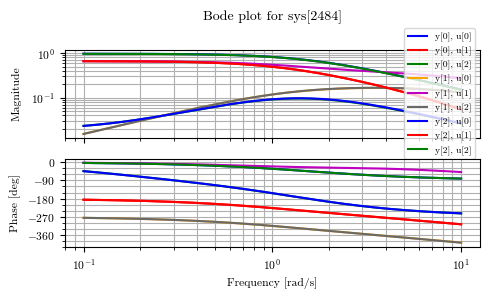

In [2002]:
ct.frequency_response(G).plot(plot_magnitude=True,plot_phase=True, overlay_inputs=True, overlay_outputs=True)

# Model Parameter Summary

In [1970]:
# -----------------------------------------------------------------------
import pandas as pd
# -----------------------------------------------------------------------

# Model parameters
params = [p11,p12,p13,p21,p22,p23,p31,p32,p33]
# Parameter dataframe
params_df = pd.DataFrame(params,
                         columns=['K [V/V]','T1 [s]','T2 [s]','T3 [s]'])
# Relabel parameter rows
params_df.index = ['G11','G12','G13','G21','G22','G23','G31','G32','G33']
# Print parameter dataframe
display(params_df)
# -----------------------------------------------------------------------

,K [V/V],T1 [s],T2 [s],T3 [s]
G11,0.973226,0.631297,NaN,NaN
G12,-0.662414,0.096102,0.880083,NaN
G13,0.018948,0.716714,0.716695,-7.187588
G21,0.209229,0.831769,0.097891,NaN
G22,0.663027,0.899383,0.096022,0.500199
G23,0.213358,0.817818,0.100943,NaN
G31,0.018757,0.711688,0.711696,-7.315993
G32,-0.662971,0.095352,0.885273,NaN
G33,0.968779,0.636545,NaN,NaN


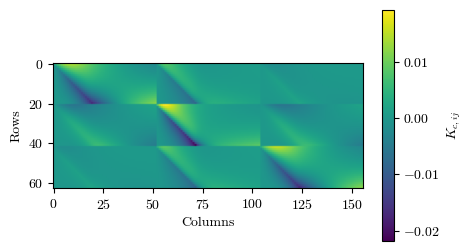

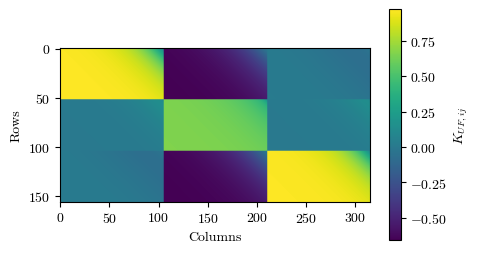

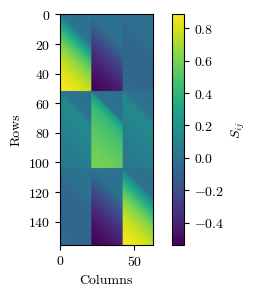

In [2176]:
# -----------------------------------------------------------------------
from scipy.sparse import spdiags
from scipy.linalg import block_diag
# -----------------------------------------------------------------------

# Sample time
dt = 0.03

# Number of inputs
m = 3
# Number of outputs
r = 3
# Model horizon
N = 105
# Input horizon
M = int(0.2*N)
# Prediction horizon
P = int(0.5*N)

# Q-weighting matrix
Q = np.eye(m*P)
# R-weighting matrix
#R = 1e1*np.eye(r*M)
R = 1e1*np.eye(r*M)

# 'Infinite' time
t_inf = 1e6

# -----------------------------------------------------------------------
# Function setup to get MPC matrices

# Function to get step response model for single I/O pair
def get_step_mtx(f,dt,M,P):
    S = np.zeros((P,M))
    t = np.arange(dt,(P+1)*dt,dt)
    S[:,0] = f(t)
    for i in range(1,M):
        S[i:,i] = S[0:P-i,0]
    return S

# Function to get unforced response model for single I/O pair
def get_unforced_mtx(f,dt,N,P):
    S = np.zeros((P,N))
    t = np.arange(0,(N+P+1)*dt,dt)
    a = f(t)
    for i in range(0,N):
        S[:,i] = a[(N+1-i):(P+N+1-i)]
    return S
# -----------------------------------------------------------------------
# Get step response matrices for each I/O pair

S11 = get_step_mtx(lambda t: g11(t,*p11),dt,M,P)
S12 = get_step_mtx(lambda t: g12(t,*p12),dt,M,P)
S13 = get_step_mtx(lambda t: g13(t,*p13),dt,M,P)

S21 = get_step_mtx(lambda t: g21(t,*p21),dt,M,P)
S22 = get_step_mtx(lambda t: g22(t,*p22),dt,M,P)
S23 = get_step_mtx(lambda t: g23(t,*p23),dt,M,P)

S31 = get_step_mtx(lambda t: g31(t,*p31),dt,M,P)
S32 = get_step_mtx(lambda t: g32(t,*p32),dt,M,P)
S33 = get_step_mtx(lambda t: g33(t,*p33),dt,M,P)

# Stack submatrices into block form
S = np.block([[S11,S12,S13],[S21,S22,S23],[S31,S32,S33]])

# MPC controller gain
Kc = np.linalg.inv(S.T@Q@S+R)@S.T@Q

# -----------------------------------------------------------------------
# Get unforced response matrices for each I/O pair

UF11 = get_unforced_mtx(lambda t: g11(t,*p11),dt,N,P)
UF21 = get_unforced_mtx(lambda t: g21(t,*p21),dt,N,P)
UF31 = get_unforced_mtx(lambda t: g31(t,*p31),dt,N,P)

UF12 = get_unforced_mtx(lambda t: g12(t,*p12),dt,N,P)
UF22 = get_unforced_mtx(lambda t: g22(t,*p22),dt,N,P)
UF32 = get_unforced_mtx(lambda t: g32(t,*p32),dt,N,P)

UF13 = get_unforced_mtx(lambda t: g13(t,*p13),dt,N,P)
UF23 = get_unforced_mtx(lambda t: g23(t,*p23),dt,N,P)
UF33 = get_unforced_mtx(lambda t: g33(t,*p33),dt,N,P)

# Stack submatrices into block form
UF = np.block([[UF11,UF12,UF13],[UF21,UF22,UF23],[UF31,UF32,UF33]])

# Matrix to calculate terms to augment y0
SSU = np.array([[g11(t_inf,*p11),g12(t_inf,*p12),g13(t_inf,*p13)],
                [g21(t_inf,*p21),g22(t_inf,*p22),g23(t_inf,*p23)],
                [g31(t_inf,*p31),g32(t_inf,*p32),g33(t_inf,*p33)]])


# -----------------------------------------------------------------------
# Plot controller gain matrix
fig, ax = plt.subplots()
plt.imshow(Kc)
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.colorbar(label='$K_{c,ij}$')
plt.show()
fig.savefig('CHEN_5300_Kc_matrix.png',dpi=600,bbox_inches='tight')

# Plot unforced response matrices
fig, ax = plt.subplots()
plt.imshow(UF)
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.colorbar(label='$K_{UF,ij}$')
plt.show()
fig.savefig('CHEN_5300_K_UF_matrix.png',dpi=600,bbox_inches='tight')

# Plot step response matrices
fig, ax = plt.subplots()
plt.imshow(S)
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.colorbar(label='$S_{ij}$')
plt.show()
fig.savefig('CHEN_5300_step_resp_matrix.png',dpi=600,bbox_inches='tight')
# -----------------------------------------------------------------------

In [2152]:
print(M)
print(P)

21
52


# Model Predictive Control

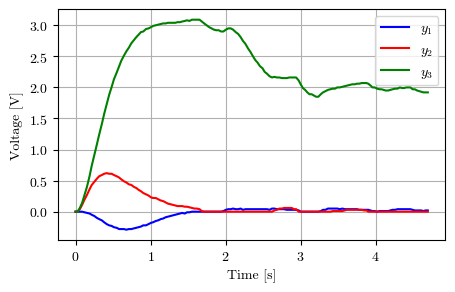

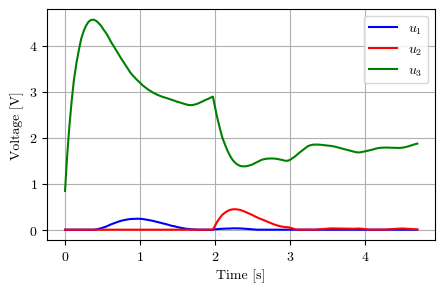

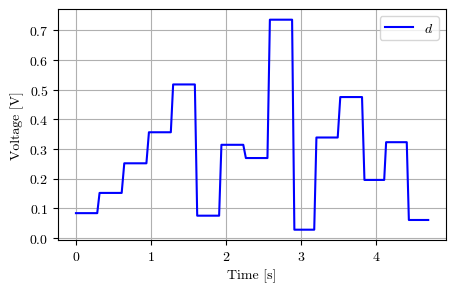

In [2156]:
# -----------------------------------------------------------------------
# Max time steps to measure
max_iter = 150

# Input functions for voltage sources
v1_sp = lambda t: 0
v2_sp = lambda t: 0
v3_sp = lambda t: 3 - np.heaviside(t-2,1)
dv = lambda t: np.abs(np.random.normal(loc=0,scale=0.3,size=1))

# Name of ouput csv file
name = 'controls_test.csv'

# -----------------------------------------------------------------------

# Establish Serial object with COM port and BAUD rate to match Arduino
try:
    ser = serial.Serial("COM9", 9600,timeout=1)
except:
    ser.close()  
    ser = serial.Serial("COM9", 9600,timeout=1)

# -----------------------------------------------------------------------
# Time delay for Arduino Serial initialization 
time.sleep(4)  

# Time vector
tt = np.zeros(max_iter)
# Vector of voltages, rows = time, cols = values
y = np.zeros((max_iter,3))
# Vector of control inputs
u = np.zeros((max_iter,3))

# Vector of unforced voltages, rows = time, cols = values
y_uf = np.zeros(m*P)
# Vector of output predictions
y_pred = np.zeros(m*P)
# Vector of initial conditions
y0 = np.zeros(m*P)
# Disturbance at time, t
d_t = np.zeros(max_iter)

# Past control moves as a stacked vector
du_past = np.zeros(r*N)
# Past control moves as a matrix, rows = past steps, cols = inputs
du_p = np.zeros((N,r))

# Vector of ones, size of prediction horizon
unit = np.ones((P,))


# Set voltages to 0 to initialize communication
v_in = np.array([0,0,0])
dig_v = ",".join(map(str, v_in)) + "\n"
ser.write(str(dig_v).encode('utf-8'))

# Loop over time steps
for i in range(max_iter):

    # Add current time to time vector
    tt[i] = time.time()
    # Read the component voltages for the Arduino
    arduinoData_string = ser.readline().decode('ascii').split(",")
    # Convert string to voltage values (float)
    values = np.array([float(j) for j in arduinoData_string[0:-1]])
    # Store in voltage vector
    y[i,:] = values
    
    # Time relative to start
    t = tt[i]-tt[0]
    # Prediction error vector
    e = values - y_pred[0::P]
    # Estimation bias as stacked vector
    bias = np.hstack([e[0]*unit,e[1]*unit,e[2]*unit])
    # Setpoint at time, t
    y_ref = np.hstack([v1_sp(t)*unit,v2_sp(t)*unit,v3_sp(t)*unit])
    
    # Unforced response
    y_uf = y0 + UF@du_past
    # Unforced error vector
    E0 = y_ref - y_uf - bias
    # Optimal control moves
    du = Kc@E0
    # Predicted y values 
    y_pred = S@du + y_uf

    # Compute input voltages
    # Store old inputs
    v_old = v_in
    # Update inputs with du move
    v_in = v_old + du[0::M]
    # Impose min, max input constraints
    v_in[v_in>5] = 5
    v_in[v_in<0] = 0
    # Store control inputs
    u[i,:] = v_in
    # Actual control move
    du[0::M] = v_in - v_old

    # Compute disturbance
    if i%10 == 0:
        d = dv(t)[0]
    d_t[i] = d

    # Convert 0-5 V to 0-255 bit range for PWM
    u_in = [int(v_in[0]*51),int(v_in[1]*51),int((v_in[2]+d)*51)]
    # String of input values
    dig_v = ",".join(map(str, u_in)) + "\n"
    # Sent string to Arduino
    ser.write(str(dig_v).encode('utf-8'))

    # Update control move history
    du_p = np.roll(du_p,-1,axis=0)
    # Augement y0 to account for moves that have reached steady state
    y0_update = SSU@du_p[-1,:]
    y0 += np.hstack([y0_update[0]*unit,y0_update[1]*unit,y0_update[2]*unit])
    # Replace latest control move with the current
    du_p[-1,:] = du[0::M]
    # Vectorize control move matrix
    du_past = du_p.flatten('F')

# Set voltages to 0 once done
v_in = [0,0,0]
dig_v = ",".join(map(str, v_in)) + "\n"
ser.write(str(dig_v).encode('utf-8'))
# Close serial connection
ser.close()

# Time vector relative to start
t = tt - tt[0]
# -----------------------------------------------------------------------
# Plot results
# -----------------------------------------------------------------------
# Output voltages
fig, ax = plt.subplots()
plt.plot(t,y,label=['$y_1$','$y_2$','$y_3$'])
plt.xlabel('Time [s]')
plt.ylabel('Voltage [V]')
plt.legend()
plt.grid()
plt.show()
fig.savefig('CHEN_5300_y3_3V_dist_M21_P52_y.png',dpi=600,bbox_inches='tight')
# -----------------------------------------------------------------------
# Control inputs
fig, ax = plt.subplots()
plt.plot(t,u,label=['$u_1$','$u_2$','$u_3$'])
plt.xlabel('Time [s]')
plt.ylabel('Voltage [V]')
plt.legend()
plt.grid()
fig.savefig('CHEN_5300_y3_3V_dist_M21_P52_u.png',dpi=600,bbox_inches='tight')
# -----------------------------------------------------------------------
# Disturbance inputs
fig, ax = plt.subplots()
plt.plot(t,d_t,label='$d$')
plt.xlabel('Time [s]')
plt.ylabel('Voltage [V]')
plt.legend()
plt.grid()
fig.savefig('CHEN_5300_y3_3V_dist_M21_P52_d.png',dpi=600,bbox_inches='tight')
# -----------------------------------------------------------------------
# Save data to csv file
data = np.hstack([t[:,np.newaxis],y])
np.savetxt(name, data, delimiter=",")
# -----------------------------------------------------------------------

In [2121]:
print(np.mean(np.diff(t)))

0.030636713808814952


# PID Control Setup

In [2164]:
# -----------------------------------------------------------------------
# Controller gains (IMC)
Kc = 0.3*np.array([3/(p11[1]*p11[0]),
                   3*(p22[1]+p22[2]-p22[3])/(p22[0]*p22[1]),
                   3/(p33[1]*p33[0])])

# Controller integral time (IMC)
tau_I = 0.5*np.array([p11[1],p22[1]+p22[2]-p22[3],p33[1]])

# Print PID parameters
PID_params = pd.DataFrame([Kc,tau_I],columns=['PI 1', 'PI 2', 'PI 3'])
PID_params.index = ['Kc [-]','TI [s]']

display(PID_params)
# -----------------------------------------------------------------------

,PI 1,PI 2,PI 3
Kc [-],1.464857,0.747400,1.459448
TI [s],0.315648,0.247603,0.318273


# PID Control

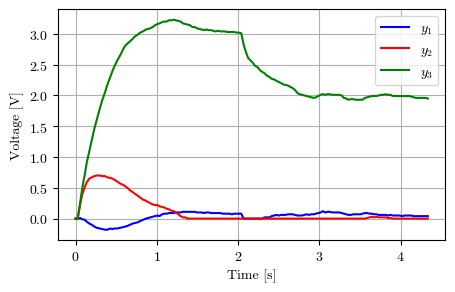

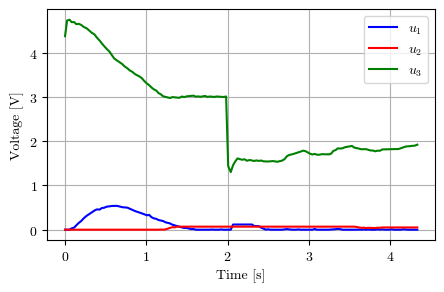

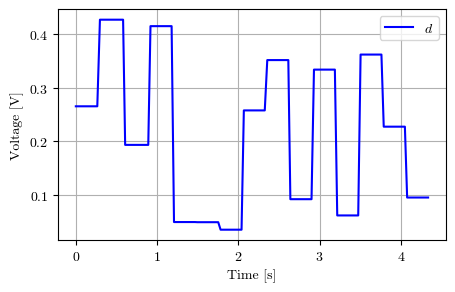

In [2174]:
# -----------------------------------------------------------------------
# Max time steps to measure
max_iter = 150

# Input functions for voltage sources
v1_sp = lambda t: 0
v2_sp = lambda t: 0
v3_sp = lambda t: 3 - np.heaviside(t-2,1)
dv = lambda t: np.abs(np.random.normal(loc=0,scale=0.3,size=1))

# Name of ouput csv file
name = 'controls_test.csv'

# -----------------------------------------------------------------------

# Establish Serial object with COM port and BAUD rate to match Arduino
try:
    ser = serial.Serial("COM9", 9600,timeout=1)
except:
    ser.close()  
    ser = serial.Serial("COM9", 9600,timeout=1)

# -----------------------------------------------------------------------
# Time delay for Arduino Serial initialization 
time.sleep(4)  

# Time vector
tt = np.zeros(max_iter)
# Vector of voltages, rows = time, cols = values
y = np.zeros((max_iter,3))
# Vector of control inputs
u = np.zeros((max_iter,3))

anti_wind = np.ones(3)

# Current error vector
e = np.zeros(3)
# Old error vector
e_old = np.zeros(3)
# Time step
dt = 0

# Disturbance at time, t
d_t = np.zeros(max_iter)


# Set voltages to 0 to initialize communication
v_in = np.array([0,0,0])
dig_v = ",".join(map(str, v_in)) + "\n"
ser.write(str(dig_v).encode('utf-8'))

# Loop over time steps
for i in range(max_iter):

    # Add current time to time vector
    tt[i] = time.time()
    # Read the component voltages for the Arduino
    arduinoData_string = ser.readline().decode('ascii').split(",")
    # Convert string to voltage values (float)
    values = np.array([float(j) for j in arduinoData_string[0:-1]])
    # Store in voltage vector
    y[i,:] = values
    
    # Time relative to start
    t = tt[i]-tt[0]
    if i > 0:
        dt = tt[i] - tt[i-1]
    # Error vector
    e = np.array([v1_sp(t),v2_sp(t),v3_sp(t)]) - values

    du = anti_wind*Kc*(e-e_old + e*dt/tau_I)
    e_old = e
    
    # Compute input voltages
    # Store old inputs
    v_old = v_in
    # Update inputs with du move
    v_in = v_old + du
    # Impose min, max input constraints
    v_in[v_in>5] = 5
    v_in[v_in<0] = 0
    
    anti_wind[:] = 1
    anti_wind[v_in>5] = 0
    anti_wind[v_in<0] = 0
    
    # Store control inputs
    u[i,:] = v_in
    # Actual control move
    du = v_in - v_old

    # Compute disturbance
    if i%10 == 0:
        d = dv(t)[0]
    d_t[i] = d

    # Convert 0-5 V to 0-255 bit range for PWM
    u_in = [int(v_in[0]*51),int(v_in[1]*51),int((v_in[2]+d)*51)]
    # String of input values
    dig_v = ",".join(map(str, u_in)) + "\n"
    # Sent string to Arduino
    ser.write(str(dig_v).encode('utf-8'))

# Set voltages to 0 once done
v_in = [0,0,0]
dig_v = ",".join(map(str, v_in)) + "\n"
ser.write(str(dig_v).encode('utf-8'))
# Close serial connection
ser.close()

# Time vector relative to start
t = tt - tt[0]
# -----------------------------------------------------------------------
# Plot results
# -----------------------------------------------------------------------
# Output voltages
fig, ax = plt.subplots()
plt.plot(t,y,label=['$y_1$','$y_2$','$y_3$'])
plt.xlabel('Time [s]')
plt.ylabel('Voltage [V]')
plt.legend()
plt.grid()
plt.show()
fig.savefig('CHEN_5300_y3_3V_dist_PID_y.png',dpi=600,bbox_inches='tight')
# -----------------------------------------------------------------------
# Control inputs
fig, ax = plt.subplots()
plt.plot(t,u,label=['$u_1$','$u_2$','$u_3$'])
plt.xlabel('Time [s]')
plt.ylabel('Voltage [V]')
plt.legend()
plt.grid()
plt.show()
fig.savefig('CHEN_5300_y3_3V_dist_PID_u.png',dpi=600,bbox_inches='tight')
# -----------------------------------------------------------------------
# Disturbance inputs
fig, ax = plt.subplots()
plt.plot(t,d_t,label='$d$')
plt.xlabel('Time [s]')
plt.ylabel('Voltage [V]')
plt.legend()
plt.grid()
plt.show()
fig.savefig('CHEN_5300_y3_3V_dist_PID_d.png',dpi=600,bbox_inches='tight')
# -----------------------------------------------------------------------
# Save data to csv file
data = np.hstack([t[:,np.newaxis],y])
np.savetxt(name, data, delimiter=",")
# -----------------------------------------------------------------------